# Matched-Score Flexibility Release

Test the hypothesis that flexibility predicts future solvability beyond Ramsey score. For each pair, start from one identical random coloring, construct a greedy seed and a flexibility-preserving seed, stop both on their first crossing of the same target score, reset all search memory, then release both into identical exact greedy+tabu searches.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from ramsey.RAction import analyze_actions
from ramsey.RColoring import RColoring
from ramsey.REnvironment import REnvironment
from ramsey.REnvironmentConfig import REnvironmentConfig, RTabuMemoryConfig
from ramsey.REnvironmentMemory import RTabuMemory
from ramsey.RFlexibility import calculate_flexibility
from ramsey.RFlexibilityPolicy import (
    RFlexibilityPolicyConfig,
    select_flexibility_action,
)
from ramsey.RGraph import RGraph
from ramsey.RObjective import RMonochromaticObjective
from ramsey.RProblem import RProblem

RANDOM_SEED = 202_608_073
NUMBER_OF_PAIRS = 3
TARGET_SCORE = 550
BUILDER_MAX_STEPS = 256
RELEASE_STEPS = 256
REPORT_INTERVAL = 32

FLEXIBILITY_BUDGETS = (0, 1, 2, 5, 10, 20)
MONITOR_BUDGET = 5
FLEXIBILITY_FLOOR = 0.55
MAXIMUM_TEMPORARY_DAMAGE = 5

EDGE_TABU_TENURE = 20
VISITED_STATE_WINDOW = 2_000

graph = RGraph(RProblem.r55(n_vertices=43))
master_rng = np.random.default_rng(RANDOM_SEED)

flex_config = RFlexibilityPolicyConfig(
    budgets=FLEXIBILITY_BUDGETS,
    monitor_budget=MONITOR_BUDGET,
    flexibility_floor=FLEXIBILITY_FLOOR,
    maximum_temporary_damage=MAXIMUM_TEMPORARY_DAMAGE,
)

initial_colorings = [
    RColoring(
        graph,
        master_rng.integers(
            0, 2, size=graph.number_of_edges, dtype=np.uint8
        ),
    )
    for _ in range(NUMBER_OF_PAIRS)
]

print('Pairs:', NUMBER_OF_PAIRS)
print('Target score:', TARGET_SCORE)
print('Release steps:', RELEASE_STEPS)
print(f'Flexibility controller: F({MONITOR_BUDGET}) >= {FLEXIBILITY_FLOOR:.1%}')
print('Maximum temporary damage:', MAXIMUM_TEMPORARY_DAMAGE)


Pairs: 3
Target score: 550
Release steps: 256
Flexibility controller: F(5) >= 55.0%
Maximum temporary damage: 5


In [2]:
def make_environment(max_steps):
    return REnvironment(
        graph=graph,
        objective=RMonochromaticObjective(),
        memory=RTabuMemory(
            graph.number_of_edges,
            RTabuMemoryConfig(
                edge_tenure=EDGE_TABU_TENURE,
                visited_state_window=VISITED_STATE_WINDOW,
            ),
        ),
        config=REnvironmentConfig(max_steps=max_steps),
    )


def flexibility_profile(environment):
    analysis = environment.analyze_actions()
    return calculate_flexibility(
        analysis.action_analysis.immediate_rewards,
        FLEXIBILITY_BUDGETS,
    )


def greedy_edge(environment, rng):
    analysis = environment.analyze_actions()
    rewards = analysis.action_analysis.immediate_rewards
    available = analysis.available_mask
    best_reward = rewards[available].max()
    candidates = np.flatnonzero(
        available & (rewards == best_reward)
    )
    return int(rng.choice(candidates))


def state_record(environment, step):
    profile = flexibility_profile(environment)
    return {
        'step': step,
        'score': environment.state.score,
        'best_score': environment.best_score,
        'F0': profile.fraction_at(0),
        'F1': profile.fraction_at(1),
        'F2': profile.fraction_at(2),
        'F5': profile.fraction_at(5),
        'F10': profile.fraction_at(10),
        'F20': profile.fraction_at(20),
    }


In [3]:
def build_matched_seed(initial_coloring, *, mode, rng):
    environment = make_environment(BUILDER_MAX_STEPS)
    environment.reset(initial_coloring)
    trajectory = [state_record(environment, 0)]
    reorganization_steps = 0
    start = perf_counter()

    while environment.state.score > TARGET_SCORE:
        if environment.truncated:
            raise RuntimeError(
                f'{mode} builder did not reach target score '
                f'{TARGET_SCORE} within {BUILDER_MAX_STEPS} steps; '
                f'final score was {environment.state.score}.'
            )

        if mode == 'greedy':
            edge = greedy_edge(environment, rng)
        elif mode == 'flexibility':
            decision = select_flexibility_action(
                environment, rng, flex_config
            )
            edge = decision.edge
            reorganization_steps += decision.mode == 'flexibility'
        else:
            raise ValueError(f'Unknown builder mode: {mode}')

        environment.step(edge, full_analysis=True)
        trajectory.append(state_record(environment, environment.step_number))

    elapsed = perf_counter() - start
    profile = flexibility_profile(environment)

    return {
        'mode': mode,
        'coloring': environment.state.coloring_snapshot(),
        'score': environment.state.score,
        'F0': profile.fraction_at(0),
        'F5': profile.fraction_at(5),
        'steps': environment.step_number,
        'reorganization_steps': int(reorganization_steps),
        'elapsed': elapsed,
        'trajectory': trajectory,
    }


In [4]:
matched_pairs = []

for pair_number, initial_coloring in enumerate(initial_colorings):
    print()
    print(f'BUILD PAIR {pair_number}')
    pair = {'pair': pair_number}
    tie_seed = RANDOM_SEED + 10_000 + pair_number

    for mode in ('greedy', 'flexibility'):
        seed = build_matched_seed(
            initial_coloring,
            mode=mode,
            rng=np.random.default_rng(tie_seed),
        )
        pair[mode] = seed
        print(
            f'  {mode:11s} | score={seed["score"]:4d} | '
            f'F0={seed["F0"]:7.3%} | F5={seed["F5"]:7.3%} | '
            f'steps={seed["steps"]:3d} | '
            f'reorg={seed["reorganization_steps"]:3d} | '
            f'time={seed["elapsed"]:.1f}s'
        )

    pair['score_gap'] = abs(pair['greedy']['score'] - pair['flexibility']['score'])
    pair['F5_gap'] = pair['flexibility']['F5'] - pair['greedy']['F5']
    print(
        f'  matched score gap={pair["score_gap"]} | '
        f'flexibility advantage={pair["F5_gap"]:+.3%}'
    )
    matched_pairs.append(pair)



BUILD PAIR 0
  greedy      | score= 548 | F0=14.507% | F5=44.740% | steps= 51 | reorg=  0 | time=0.2s
  flexibility | score= 549 | F0=12.625% | F5=54.817% | steps=106 | reorg= 41 | time=92.2s
  matched score gap=1 | flexibility advantage=+10.078%

BUILD PAIR 1
  greedy      | score= 550 | F0=16.501% | F5=45.183% | steps= 59 | reorg=  0 | time=0.2s
  flexibility | score= 550 | F0=15.836% | F5=52.602% | steps=107 | reorg= 38 | time=75.5s
  matched score gap=0 | flexibility advantage=+7.420%

BUILD PAIR 2
  greedy      | score= 549 | F0=14.396% | F5=45.183% | steps= 49 | reorg=  0 | time=0.1s
  flexibility | score= 548 | F0=15.504% | F5=54.153% | steps=100 | reorg= 39 | time=92.5s
  matched score gap=1 | flexibility advantage=+8.970%


In [5]:
def release_greedy(seed_coloring, *, rng):
    environment = make_environment(RELEASE_STEPS)
    environment.reset(seed_coloring)
    trajectory = [state_record(environment, 0)]
    start = perf_counter()

    while not (environment.terminated or environment.truncated):
        edge = greedy_edge(environment, rng)
        environment.step(edge, full_analysis=True)
        trajectory.append(state_record(environment, environment.step_number))

        if environment.step_number % REPORT_INTERVAL == 0:
            current = trajectory[-1]
            print(
                f'    step={environment.step_number:3d} | '
                f'score={current["score"]:4d} | '
                f'best={current["best_score"]:4d} | '
                f'F0={current["F0"]:7.3%} | F5={current["F5"]:7.3%}'
            )

    elapsed = perf_counter() - start
    final = trajectory[-1]
    return {
        'initial_score': trajectory[0]['score'],
        'initial_F0': trajectory[0]['F0'],
        'initial_F5': trajectory[0]['F5'],
        'final_score': final['score'],
        'best_score': environment.best_score,
        'final_F0': final['F0'],
        'final_F5': final['F5'],
        'steps': environment.step_number,
        'elapsed': elapsed,
        'trajectory': trajectory,
    }


for pair in matched_pairs:
    print()
    print(f'RELEASE PAIR {pair["pair"]}')
    release_seed = RANDOM_SEED + 20_000 + pair['pair']

    for mode in ('greedy', 'flexibility'):
        print(f'  Releasing {mode} seed...')
        release = release_greedy(
            pair[mode]['coloring'],
            rng=np.random.default_rng(release_seed),
        )
        pair[mode]['release'] = release
        print(
            f'  {mode:11s} COMPLETE | '
            f'{release["initial_score"]:4d}->{release["final_score"]:4d} | '
            f'best={release["best_score"]:4d} | '
            f'F5={release["initial_F5"]:7.3%}->{release["final_F5"]:7.3%} | '
            f'time={release["elapsed"]:.1f}s'
        )



RELEASE PAIR 0
  Releasing greedy seed...
    step= 32 | score= 409 | best= 409 | F0= 7.198% | F5=34.773%
    step= 64 | score= 325 | best= 325 | F0= 2.547% | F5=28.682%
    step= 96 | score= 285 | best= 285 | F0= 1.329% | F5=24.031%
    step=128 | score= 261 | best= 261 | F0= 1.218% | F5=22.370%
    step=160 | score= 247 | best= 247 | F0= 0.997% | F5=21.373%
    step=192 | score= 230 | best= 230 | F0= 0.886% | F5=19.823%
    step=224 | score= 217 | best= 215 | F0= 0.886% | F5=19.491%
    step=256 | score= 207 | best= 207 | F0= 0.775% | F5=18.051%
  greedy      COMPLETE |  548-> 207 | best= 207 | F5=44.740%->18.051% | time=0.8s
  Releasing flexibility seed...
    step= 32 | score= 408 | best= 408 | F0= 5.316% | F5=36.545%
    step= 64 | score= 321 | best= 321 | F0= 2.547% | F5=29.790%
    step= 96 | score= 277 | best= 277 | F0= 0.554% | F5=24.363%
    step=128 | score= 256 | best= 256 | F0= 1.440% | F5=22.481%
    step=160 | score= 239 | best= 239 | F0= 0.554% | F5=20.819%
    step=19

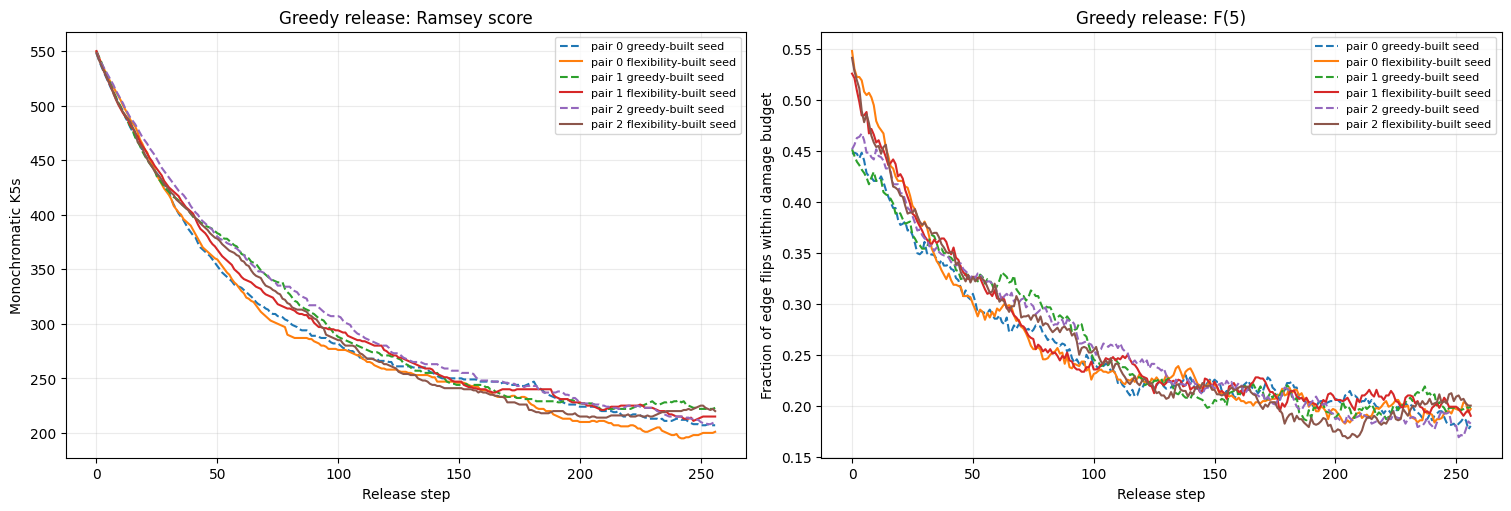

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

for pair in matched_pairs:
    for mode, linestyle in (('greedy', '--'), ('flexibility', '-')):
        trajectory = pair[mode]['release']['trajectory']
        steps = [row['step'] for row in trajectory]
        scores = [row['score'] for row in trajectory]
        f5 = [row['F5'] for row in trajectory]
        label = f'pair {pair["pair"]} {mode}-built seed'
        axes[0].plot(steps, scores, linestyle, label=label)
        axes[1].plot(steps, f5, linestyle, label=label)

axes[0].set_title('Greedy release: Ramsey score')
axes[0].set_ylabel('Monochromatic K5s')
axes[1].set_title('Greedy release: F(5)')
axes[1].set_ylabel('Fraction of edge flips within damage budget')

for ax in axes:
    ax.set_xlabel('Release step')
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.show()


In [7]:
print('MATCHED-SCORE FLEXIBILITY RELEASE REPORT')
print('=' * 100)
print(
    f'target={TARGET_SCORE}, release_steps={RELEASE_STEPS}, '
    f'F({MONITOR_BUDGET}) floor={FLEXIBILITY_FLOOR:.1%}, '
    f'max_damage={MAXIMUM_TEMPORARY_DAMAGE}'
)
print()

greedy_best = []
flex_best = []

for pair in matched_pairs:
    print(f'Pair {pair["pair"]}:')
    print(
        f'  seed match | score gap={pair["score_gap"]} | '
        f'F5 advantage={pair["F5_gap"]:+.3%}'
    )
    for mode in ('greedy', 'flexibility'):
        seed = pair[mode]
        release = seed['release']
        print(
            f'  {mode:11s} seed | score={seed["score"]:4d} | '
            f'F0={seed["F0"]:7.3%} | F5={seed["F5"]:7.3%} | '
            f'release_final={release["final_score"]:4d} | '
            f'release_best={release["best_score"]:4d} | '
            f'final_F0={release["final_F0"]:7.3%} | '
            f'final_F5={release["final_F5"]:7.3%}'
        )
    greedy_best.append(pair['greedy']['release']['best_score'])
    flex_best.append(pair['flexibility']['release']['best_score'])
    print(
        '  best-score advantage of flexible seed: '
        f'{pair["greedy"]["release"]["best_score"] - pair["flexibility"]["release"]["best_score"]:+d}'
    )
    print()

print('Mean greedy-built release best:', f'{np.mean(greedy_best):.2f}')
print('Mean flexibility-built release best:', f'{np.mean(flex_best):.2f}')
print(
    'Mean best-score advantage of flexibility-built seeds:',
    f'{np.mean(np.asarray(greedy_best) - np.asarray(flex_best)):+.2f}',
)


MATCHED-SCORE FLEXIBILITY RELEASE REPORT
target=550, release_steps=256, F(5) floor=55.0%, max_damage=5

Pair 0:
  seed match | score gap=1 | F5 advantage=+10.078%
  greedy      seed | score= 548 | F0=14.507% | F5=44.740% | release_final= 207 | release_best= 207 | final_F0= 0.775% | final_F5=18.051%
  flexibility seed | score= 549 | F0=12.625% | F5=54.817% | release_final= 201 | release_best= 195 | final_F0= 0.443% | final_F5=19.712%
  best-score advantage of flexible seed: +12

Pair 1:
  seed match | score gap=0 | F5 advantage=+7.420%
  greedy      seed | score= 550 | F0=16.501% | F5=45.183% | release_final= 223 | release_best= 221 | final_F0= 0.886% | final_F5=19.934%
  flexibility seed | score= 550 | F0=15.836% | F5=52.602% | release_final= 215 | release_best= 211 | final_F0= 0.886% | final_F5=19.048%
  best-score advantage of flexible seed: +10

Pair 2:
  seed match | score gap=1 | F5 advantage=+8.970%
  greedy      seed | score= 549 | F0=14.396% | F5=45.183% | release_final= 210 | 